In [8]:
import torch
import numpy as np

X=torch.tensor(np.array([[1.0,1.0,1.0],[1.0,2.0,3.0]]),requires_grad=True).T
W=torch.tensor(np.array([4.0,0.0]),requires_grad=True)
y= torch.tensor(np.array([1,2,3.0]),dtype=torch.float32)
print(X,W,y)

tensor([[1., 1.],
        [1., 2.],
        [1., 3.]], dtype=torch.float64, grad_fn=<PermuteBackward0>) tensor([4., 0.], dtype=torch.float64, requires_grad=True) tensor([1., 2., 3.])


In [3]:
l=0.5*((X@W-y)**2).sum()

In [4]:
l.backward()
print(W.grad)
print(X.grad)

tensor([5.2000, 6.8000, 8.4000], dtype=torch.float64)
tensor([[0.0400, 0.0800, 0.1200],
        [0.1200, 0.2400, 0.3600]], dtype=torch.float64)


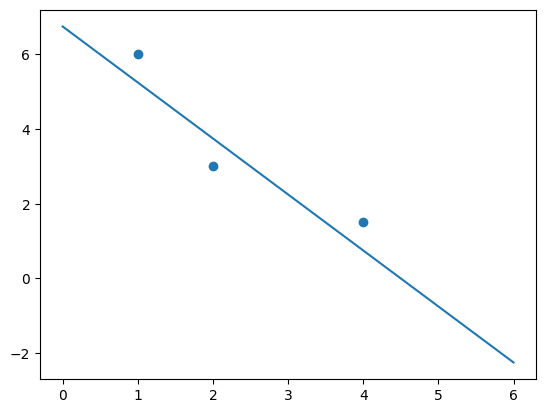

In [10]:
plt.plot(np.linspace(0,6,10),np.linspace(0,6,10)*(-39/26)+27/4)
plt.scatter([1,2,4],[6,3,1.5])
plt.show()

In [2]:
pred=X@W

In [5]:
X.T@(pred-y)

tensor([ 6., 10.], dtype=torch.float64, grad_fn=<MvBackward0>)

In [11]:
for i in range(10):
    pred=X@W
    l=0.5*((pred-y)**2).sum()
    l.backward()
    W.data-=1*W.grad
    W.grad.zero_()

    print("prediction:",pred)
    print("loss:",l)
    print("weight:",W)
    print()

prediction: tensor([1.0367, 2.0079, 2.9791], dtype=torch.float64, grad_fn=<MvBackward0>)
loss: tensor(0.0009, dtype=torch.float64, grad_fn=<MulBackward0>)
weight: tensor([0.0419, 0.9816], dtype=torch.float64, requires_grad=True)

prediction: tensor([1.0234, 2.0050, 2.9866], dtype=torch.float64, grad_fn=<MvBackward0>)
loss: tensor(0.0004, dtype=torch.float64, grad_fn=<MulBackward0>)
weight: tensor([0.0268, 0.9882], dtype=torch.float64, requires_grad=True)

prediction: tensor([1.0150, 2.0032, 2.9914], dtype=torch.float64, grad_fn=<MvBackward0>)
loss: tensor(0.0002, dtype=torch.float64, grad_fn=<MulBackward0>)
weight: tensor([0.0171, 0.9925], dtype=torch.float64, requires_grad=True)

prediction: tensor([1.0096, 2.0021, 2.9945], dtype=torch.float64, grad_fn=<MvBackward0>)
loss: tensor(6.3050e-05, dtype=torch.float64, grad_fn=<MulBackward0>)
weight: tensor([0.0109, 0.9952], dtype=torch.float64, requires_grad=True)

prediction: tensor([1.0061, 2.0013, 2.9965], dtype=torch.float64, grad_fn=<M

In [ ]:
## create an interactive plot with sliders for a and b
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider
# Make sliders bigger by setting layout and style
from ipywidgets import Layout
from IPython.display import clear_output
slider_layout = Layout(width='1000px', height='40px')
a=FloatSlider(min=-10,max=10,step=0.01,value=0, description='a', layout=slider_layout, style={'description_width': 'initial'})
b=FloatSlider(min=-2,max=2,step=0.01,value=1, description='b', layout=slider_layout, style={'description_width': 'initial'})

@interact(a=a,b=b)
def plot(a,b):
    clear_output(wait=True)
    y_pred=a+x/b
    plt.figure(figsize=(15,7))
    plt.plot(x,y_pred)
    plt.scatter([1,2,4],[6,3,1.5])
    plt.text(3,8,f'loss={((y_pred-np.array([6,3,1.5]))**2).sum():.2f}',fontsize=20)
    plt.ylim(0,10)
    plt.show()


interactive(children=(FloatSlider(value=0.0, description='a', layout=Layout(height='40px', width='1000px'), ma…

In [16]:
28/39

0.717948717948718